In [15]:
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
import tensorflow as tf
tf.keras.utils.set_random_seed(42)
tf.config.experimental.enable_op_determinism()

In [16]:
data = pd.read_csv(r"/content/aapl_2014_2023-selected-columns.csv")

In [17]:
data.describe()

,open,high,low,close,volume,rsi_7
count,2516.000000,2516.000000,2516.000000,2516.000000,2.516000e+03,2516.000000
mean,77.856671,78.704468,77.060193,77.920721,1.366662e+08,55.829312
std,56.171865,56.808974,55.581734,56.226768,8.403551e+07,17.720405
min,17.684999,17.911785,17.626785,17.849285,2.404830e+07,7.771611
25%,29.740001,29.976250,29.554375,29.803750,8.138358e+07,42.223776
50%,47.963749,48.534999,47.743749,48.107500,1.121606e+08,56.567948
75%,134.792496,135.995002,133.325004,134.562497,1.668892e+08,70.072551
max,198.020004,199.619995,197.000000,198.110001,1.065523e+09,94.046150


In [18]:
data_clean = data.copy()
data.columns


Index(['date', 'open', 'high', 'low', 'close', 'volume', 'rsi_7'], dtype='object')

In [19]:
duplicate_count = data_clean.duplicated().sum()
print(duplicate_count)

0


In [20]:
missing_data = data_clean.isnull().sum()
print(missing_data)

date      0
open      0
high      0
low       0
close     0
volume    0
rsi_7     0
dtype: int64


<Axes: ylabel='close'>

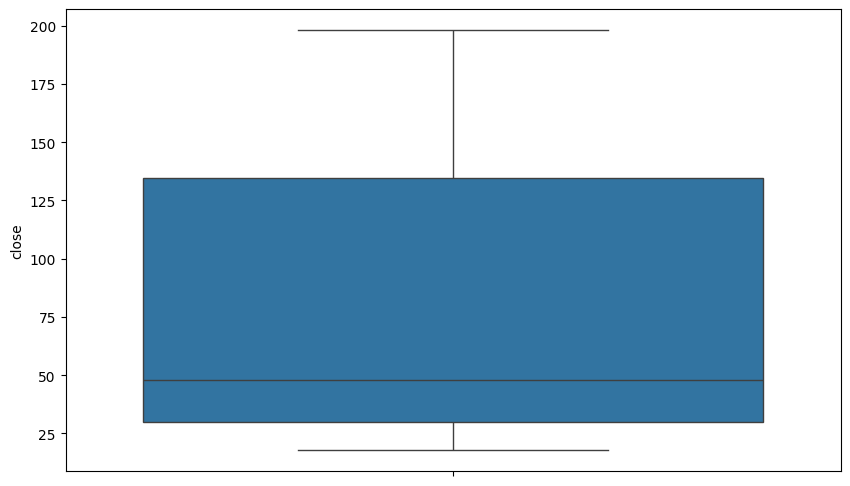

In [21]:
plt.figure(figsize=(10,6))
sb.boxplot(data_clean['close'])

In [22]:
data_clean['date'] = pd.to_datetime(data_clean['date'], format='%Y-%m-%d')
data_clean = data_clean.sort_values(by='date')
split_point = int(len(data_clean) * 0.8)
data_train = data_clean.iloc[:split_point]
data_test = data_clean.iloc[split_point:]
print(split_point)
print(data_train.shape)
print(data_test.shape)

2012
(2012, 7)
(504, 7)


# training set raw data

In [23]:
# Create X_train_features_raw by dropping only 'date' from data_train
X_train_features_raw = data_train.drop(columns=['date']).copy()

# Define y_train_target_raw (next day's close price)
y_train_target_raw = data_train['close'].shift(-1)

# Align X and y by dropping the last row from both as y_train_target_raw will have a NaN
X_train_features_raw = X_train_features_raw.iloc[:-1]
y_train_target_raw = y_train_target_raw.iloc[:-1]
print(f"Shape of X_train_features_raw: {X_train_features_raw.shape}")
print(f"Shape of y_train_target_raw: {y_train_target_raw.shape}")
print(X_train_features_raw.columns)



Shape of X_train_features_raw: (2011, 6)
Shape of y_train_target_raw: (2011,)
Index(['open', 'high', 'low', 'close', 'volume', 'rsi_7'], dtype='object')


# testing set raw data


In [24]:
X_test_features_raw = data_test.drop(columns=['date']).copy()
y_test_target_raw = data_test['close'].shift(-1)
X_test_features_raw = X_test_features_raw.iloc[:-1]
y_test_target_raw = y_test_target_raw.iloc[:-1]
print(f"Shape of X_test_features_raw: {X_test_features_raw.shape}")
print(f"Shape of y_test_target_raw: {y_test_target_raw.shape}")

Shape of X_test_features_raw: (503, 6)
Shape of y_test_target_raw: (503,)


# scaled trainig data

In [25]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# We need two separate scalers so we can inverse-transform the target later
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

# Fit and transform features
X_train_features_raw_scaled = scaler_X.fit_transform(X_train_features_raw)

# Fit and transform target (convert Series to numpy using .values before reshaping)
y_train_target_raw_scaled = scaler_y.fit_transform(y_train_target_raw.values.reshape(-1, 1))


# scaled test data

In [26]:
import numpy as np

# Pass the DataFrame directly to avoid the feature names warning
X_test_features_raw_scaled = scaler_X.transform(X_test_features_raw)

# Convert Series to numpy values and reshape before transforming with scaler_y
y_test_target_raw_scaled = scaler_y.transform(y_test_target_raw.values.reshape(-1, 1))


In [27]:
if data['close'][1] == y_train_target_raw[0]:
  print('true')

true


# slicing scaled train data

In [28]:
X_train = []
y_train = []
window = 20

for i in range(len(X_train_features_raw_scaled) - window):
    # Using the scaled versions
    X_train.append(X_train_features_raw_scaled[i:i+window])
    y_train.append(y_train_target_raw_scaled[i+window-1])

X_train = np.array(X_train)
y_train = np.array(y_train)

print(f'X_train shape: {X_train.shape}')
print(f'y_train shape: {y_train.shape}')

X_train shape: (1991, 20, 6)
y_train shape: (1991, 1)


# slicing test data

In [29]:
X_test = []
y_test = []
for i in range(len(X_test_features_raw_scaled) - window):
    # Using the scaled versions
    X_test.append(X_test_features_raw_scaled[i:i+window])
    y_test.append(y_test_target_raw_scaled[i+window-1])
X_test = np.array(X_test)
y_test = np.array(y_test)
print(f'X_test shape: {X_test.shape}')
print(f'y_test shape: {y_test.shape}')

X_test shape: (483, 20, 6)
y_test shape: (483, 1)


# model

In [30]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

model = Sequential()
model.add(Input(shape=(20, 6)))
# model.add(LSTM(units=64, return_sequences=True))
# model.add(Dropout(0.2))
model.add(LSTM(units=128, return_sequences=False))
model.add(Dense(units=1))

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 128)            │        69,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 69,249 (270.50 KB)

 Trainable params: 69,249 (270.50 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2, shuffle=False,)



Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0018 - val_loss: 0.0029
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0022 - val_loss: 0.0010
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 2.6922e-04 - val_loss: 6.2691e-04
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 3.1328e-04 - val_loss: 6.6334e-04
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 3.3595e-04 - val_loss: 8.5420e-04
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 3.5650e-04 - val_loss: 6.1595e-04
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 3.5010e-04 - val_loss: 0.0016
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 3.0259e-04 - val_loss: 6.3865e-04
Epoch 9/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 1.9679e-04 - val_loss: 9.1496e-04
Epoch 10/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 1.6811e-04 - val_loss: 5.6104e-04
Epoch 11/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 1.1758e-04 - val_loss: 4.6848

# Predictions

In [32]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
predictions = model.predict(X_test)
predictions.shape


16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step


(483, 1)

# metrics

In [33]:
print(predictions[0])
print(X_test[0])
print(y_test[0])

[0.867476]
[[0.98904768 0.99086581 1.0067108  0.99415317 0.02083789 0.6730085 ]
 [0.98990428 0.99050046 1.00639719 0.98689072 0.01832365 0.61149363]
 [0.98146053 0.98234052 1.00119157 0.9830134  0.02251028 0.57795099]
 [0.97986972 1.00456709 1.00401397 1.01033965 0.06196824 0.71652006]
 [1.00923921 1.00493244 1.01285717 0.99612259 0.05691467 0.59856788]
 [0.99076089 0.98806462 0.98475941 0.96670372 0.05225611 0.41888746]
 [0.94848106 0.95840899 0.96594394 0.94873237 0.05456587 0.33908298]
 [0.94964361 0.95134519 0.96211813 0.94977863 0.044615   0.34677471]
 [0.92633161 0.94135849 0.9441807  0.94990175 0.06419142 0.34781803]
 [0.94615604 0.95767819 0.96080109 0.96768847 0.03429722 0.48903164]
 [0.9694068  0.96985711 0.98588839 0.97045801 0.03299603 0.50895289]
 [0.96732648 0.96644702 0.96688468 0.94990175 0.04246444 0.37162657]
 [0.9401597  0.94915299 0.96249442 0.95531781 0.03849674 0.41753447]
 [0.94119986 0.94160202 0.9519578  0.93519232 0.04876093 0.30483355]
 [0.93196075 0.93271147

In [34]:
predictions = scaler_y.inverse_transform(predictions)
y_test = scaler_y.inverse_transform(y_test)
mse = mean_squared_error(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)
print(f'Mean Squared Error: {mse}')
print(f'Mean Absolute Error: {mae}')
print(f'R-squared: {r2}')

Mean Squared Error: 11.377185892137305
Mean Absolute Error: 2.6664982124892833
R-squared: 0.9644079589168951


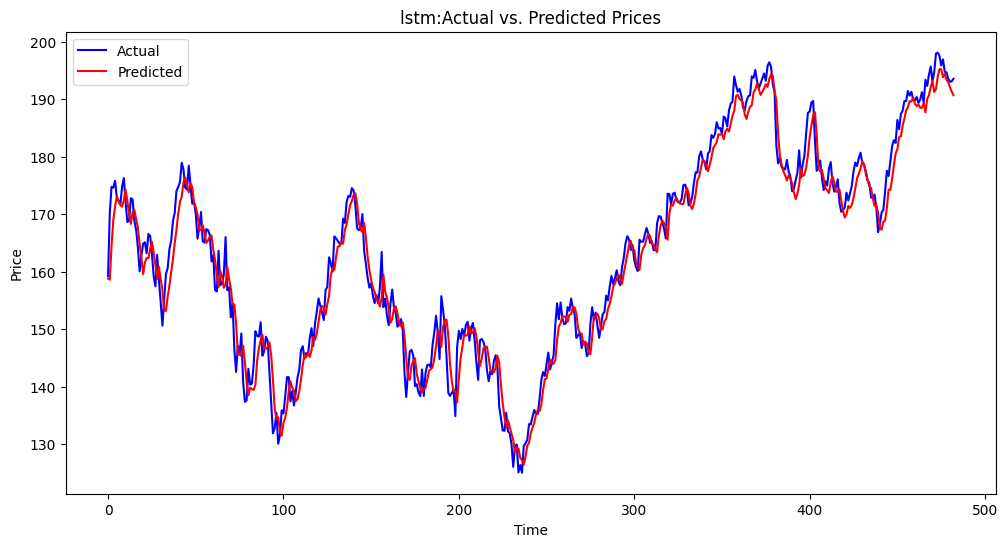

In [35]:
plt.figure(figsize=(12, 6))
plt.plot(y_test, label='Actual', color='blue')
plt.plot(predictions, label='Predicted', color='red')
plt.title('lstm:Actual vs. Predicted Prices')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

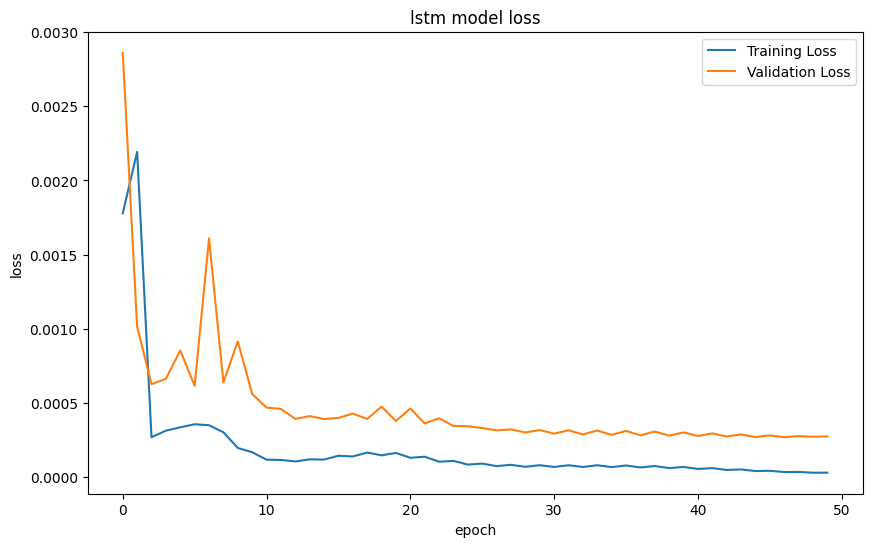

In [36]:
plt.figure(figsize=(10,6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('lstm model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(loc='upper right')
plt.show()

In [37]:
print(tf.__version__)

2.20.0
